# Harvard–Oxford Insula–DMN CPM

This notebook moves from fake ROI labels to **real atlas labels** using Nilearn's Harvard–Oxford atlas.

Goal:

1. Load your existing connectomes if available.
2. Load Harvard–Oxford atlas labels.
3. Identify insula and DMN-like regions.
4. Extract insula–DMN edges.
5. Run a CPM-style prediction.

Important: this notebook is a **real atlas workflow**, but the connectomes must have the same number/order of ROIs as the atlas. If they do not, the notebook will stop and explain why.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error, mean_squared_error

from nilearn import datasets

print("Imports OK")


Imports OK


In [2]:
# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PHENO_DIR = DATA_DIR / "phenotypes"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

for d in [PROCESSED_DIR, PHENO_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: /home/john-walkey/Data/Research/connectome


## 1. Load Harvard–Oxford atlas labels

In [3]:
# Harvard-Oxford cortical atlas
# This downloads a small atlas file the first time.
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")

atlas_filename = atlas.maps
labels = list(atlas.labels)

print("Atlas image:", atlas_filename)
print("Number of labels including background:", len(labels))
print(labels)


[fetch_atlas_harvard_oxford] Dataset found in /home/john-walkey/nilearn_data/fsl
Atlas image: 
<class 'nibabel.nifti1.Nifti1Image'>
data shape (91, 109, 91)
affine:
[[   2.    0.    0.  -90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  3  91 109  91   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 2. 2. 2. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 48.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0

## 2. Identify insula and DMN-like labels

Harvard–Oxford is anatomical, not a functional-network atlas. So "DMN" here is approximated using common anatomical nodes:

- medial frontal / frontal medial cortex
- posterior cingulate / precuneus
- angular gyrus

This is good for learning and early hypothesis work, but later we may want a functional atlas such as Schaefer/Yeo.


In [4]:
# Label 0 is usually background, so ROI indices are offset by -1 relative to label list.
# We will create a table to inspect labels.

roi_table = pd.DataFrame({
    "label_index_in_atlas": range(len(labels)),
    "label": labels
})

roi_table.to_csv(PROCESSED_DIR / "harvard_oxford_labels.csv", index=False)
roi_table.head(20)


,label_index_in_atlas,label
0,0,Background
1,1,Frontal Pole
2,2,Insular Cortex
3,3,Superior Frontal Gyrus
4,4,Middle Frontal Gyrus
5,5,"Inferior Frontal Gyrus, pars triangularis"
6,6,"Inferior Frontal Gyrus, pars opercularis"
7,7,Precentral Gyrus
8,8,Temporal Pole
9,9,"Superior Temporal Gyrus, anterior division"


In [5]:
insula_terms = ["Insular Cortex"]

dmn_terms = [
    "Frontal Medial Cortex",
    "Cingulate Gyrus, posterior division",
    "Precuneous Cortex",
    "Angular Gyrus",
]

insula_label_indices = [
    i for i, lab in enumerate(labels)
    if any(term.lower() in lab.lower() for term in insula_terms)
]

dmn_label_indices = [
    i for i, lab in enumerate(labels)
    if any(term.lower() in lab.lower() for term in dmn_terms)
]

print("Insula atlas label indices:")
for i in insula_label_indices:
    print(i, labels[i])

print("\nDMN-like atlas label indices:")
for i in dmn_label_indices:
    print(i, labels[i])


Insula atlas label indices:
2 Insular Cortex

DMN-like atlas label indices:
21 Angular Gyrus
25 Frontal Medial Cortex
30 Cingulate Gyrus, posterior division
31 Precuneous Cortex


## 3. Convert atlas label indices to connectome matrix indices

Important detail:

- Harvard–Oxford label list includes `Background` at index 0.
- A connectome usually excludes background.
- So atlas label index 1 maps to connectome ROI index 0.

Therefore:

```python
connectome_index = atlas_label_index - 1
```


In [6]:
insula_idx = np.array([i - 1 for i in insula_label_indices if i > 0])
dmn_idx = np.array([i - 1 for i in dmn_label_indices if i > 0])

print("Connectome insula indices:", insula_idx)
print("Connectome DMN-like indices:", dmn_idx)


Connectome insula indices: [1]
Connectome DMN-like indices: [20 24 29 30]


## 4. Load connectomes and phenotype

In [7]:
# Try loading previously saved files.
# These names match earlier notebooks, but adjust if your files differ.

connectome_path_options = [
    PROCESSED_DIR / "harvard_oxford_connectomes.npy",
    PROCESSED_DIR / "nki_harvard_oxford_connectomes.npy",
    PROCESSED_DIR / "simulated_connectomes.npy",
]

pheno_path_options = [
    PHENO_DIR / "nki_phenotypes.csv",
    PHENO_DIR / "simulated_trait_anxiety.csv",
]

connectome_path = next((p for p in connectome_path_options if p.exists()), None)
pheno_path = next((p for p in pheno_path_options if p.exists()), None)

print("Connectome path:", connectome_path)
print("Phenotype path:", pheno_path)

if connectome_path is None:
    raise FileNotFoundError("No connectome .npy file found in data/processed.")

connectomes = np.load(connectome_path)
print("Connectomes shape:", connectomes.shape)

if pheno_path is not None:
    pheno = pd.read_csv(pheno_path)
    print("Phenotype columns:", list(pheno.columns))
else:
    pheno = None
    print("No phenotype file found.")


Connectome path: /home/john-walkey/Data/Research/connectome/data/processed/harvard_oxford_connectomes.npy
Phenotype path: /home/john-walkey/Data/Research/connectome/data/phenotypes/nki_phenotypes.csv
Connectomes shape: (24, 48, 48)
Phenotype columns: ['participant_id', 'Age', 'AgeGroup', 'Child_Adult', 'Gender', 'Handedness']


## 5. Check atlas/connectome compatibility

This is where real workflows often fail. If the connectome was not built using the Harvard–Oxford atlas, the ROI count will not match.

That is not a disaster. It just means we need to build Harvard–Oxford connectomes from time series in the next step.


In [8]:
n_expected_rois = len(labels) - 1
n_connectome_rois = connectomes.shape[1]

print("Expected Harvard-Oxford ROIs:", n_expected_rois)
print("Connectome ROIs:", n_connectome_rois)

if n_connectome_rois != n_expected_rois:
    print("\nSTOP: These connectomes do not appear to be Harvard-Oxford connectomes.")
    print("That is OK. The atlas labels are real, but the connectome ROI count does not match.")
    print("Next step would be to extract Harvard-Oxford ROI time series from real fMRI images.")
    RUN_CPM = False
else:
    print("\nGood: connectome ROI count matches Harvard-Oxford atlas.")
    RUN_CPM = True


Expected Harvard-Oxford ROIs: 48
Connectome ROIs: 48

Good: connectome ROI count matches Harvard-Oxford atlas.


## 6. Choose target variable

In [9]:
# Choose a numeric target.
# If using public NKI phenotypes, likely options are "Age" only.
# If using simulated file, use "trait_anxiety".

if pheno is None:
    TARGET_COLUMN = None
elif "trait_anxiety" in pheno.columns:
    TARGET_COLUMN = "trait_anxiety"
elif "Age" in pheno.columns:
    TARGET_COLUMN = "Age"
else:
    TARGET_COLUMN = None

print("TARGET_COLUMN:", TARGET_COLUMN)


TARGET_COLUMN: Age


## 7. Extract insula–DMN features

In [10]:
def extract_insula_dmn_edges(conn, insula_idx, dmn_idx):
    return np.array([conn[i, j] for i in insula_idx for j in dmn_idx])

if RUN_CPM:
    X = np.array([extract_insula_dmn_edges(c, insula_idx, dmn_idx) for c in connectomes])
    print("Feature matrix shape:", X.shape)
else:
    X = None
    print("Skipping feature extraction because atlas/connectome ROI counts do not match.")


Feature matrix shape: (24, 4)


## 8. Run CPM-style prediction

In [11]:
if not RUN_CPM:
    raise RuntimeError("Cannot run CPM until connectomes are built with the Harvard-Oxford atlas.")

if TARGET_COLUMN is None:
    raise ValueError("No numeric phenotype target found. Need Age, trait_anxiety, or another numeric column.")

# quick alignment for now; later we should match by subject IDs
n = min(len(connectomes), len(pheno))
X = X[:n]
pheno_use = pheno.iloc[:n].copy()

y_all = pd.to_numeric(pheno_use[TARGET_COLUMN], errors="coerce").values
valid = np.isfinite(y_all)

X = X[valid]
y = y_all[valid]

print("Running on subjects:", len(y))
print("Target:", TARGET_COLUMN)

loo = LeaveOneOut()
y_pred = np.zeros(len(y))

for train_idx, test_idx in loo.split(X):
    model = LinearRegression()
    model.fit(X[train_idx], y[train_idx])
    y_pred[test_idx] = model.predict(X[test_idx])

r, p = pearsonr(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"Predicted vs actual r = {r:.3f}, p = {p:.4f}")
print(f"MAE = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")


Running on subjects: 24
Target: Age
Predicted vs actual r = -0.133, p = 0.5368
MAE = 8.162
RMSE = 10.671


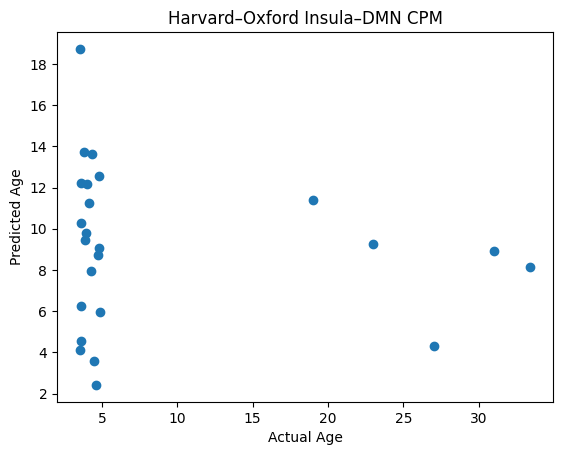

Saved: /home/john-walkey/Data/Research/connectome/results/harvard_oxford_insula_dmn_predictions.csv


In [12]:
plt.scatter(y, y_pred)
plt.xlabel(f"Actual {TARGET_COLUMN}")
plt.ylabel(f"Predicted {TARGET_COLUMN}")
plt.title("Harvard–Oxford Insula–DMN CPM")
plt.show()

out = pd.DataFrame({
    "actual": y,
    "predicted": y_pred
})
out.to_csv(RESULTS_DIR / "harvard_oxford_insula_dmn_predictions.csv", index=False)
print("Saved:", RESULTS_DIR / "harvard_oxford_insula_dmn_predictions.csv")


## Interpretation

If this notebook stops at the compatibility check, that is not failure.

It means:

- the atlas labels are real,
- but your current connectomes were not built with Harvard–Oxford ROIs.

The next real-data notebook should extract ROI time series using Harvard–Oxford from the NKI fMRI images, then save:

```text
data/processed/harvard_oxford_connectomes.npy
```

Then this notebook will run all the way through.
